In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Set the visualization style
plt.style.use('ggplot')
sns.set_palette("muted")

# ---------------------------------------------------------
# Define input pairs here. 
# Add new dictionaries to the list for future model pairs.
# ---------------------------------------------------------
input_pairs = [
    # {
    #     "model_name": "CloudFormation",
    #     "result_file": "result/iacgod/DeepseekV4Flash_security.csv",
    #     "audit_file": "result/iacgod/Trivy_DSV4_CFN_Sec.csv"
    # },
    # {
    #     "model_name": "Terraform",
    #     "result_file": "result/iacgod/Terraform_DeepseekV4Flash_security.csv",
    #     "audit_file": "result/iacgod/Trivy_DSV4_TF_Sec.csv"
    # },
    {
        "model_name": "No Planner",
        "result_file": "result/iacgod/DeepseekV4Flash_sec_ablation_no_planner.csv",
        "audit_file": "result/iacgod/Trivy_DSV4_Ablation_No_Planner.csv"
    },
    {
        "model_name": "No HyDE",
        "result_file": "result/iacgod/DeepseekV4Flash_sec_ablation_no_hyde.csv",
        "audit_file": "result/iacgod/Trivy_DSV4_Ablation_No_HyDE.csv"
    },
    {
        "model_name": "No Remediation",
        "result_file": "result/iacgod/DeepseekV4Flash_sec_ablation_no_remediation.csv",
        "audit_file": "result/iacgod/Trivy_DSV4_Ablation_No_Remediator.csv"
    },

]

policy_map_file = "Data/trivy_cfn_policy_map.csv"

In [14]:
# Load the policy map
policy_df = pd.read_csv(policy_map_file)

# Create a dictionary for fast lookup. 
# We map both the full 'AVD-AWS-XXX' format and the base 'AWS-XXX' format.
policy_mapping = {}
for _, row in policy_df.iterrows():
    check_id = str(row['check_id']).strip()
    check_name = str(row['check_name']).strip()
    check_severity = str(row['severity']).strip()
    
    policy_mapping[check_id] = f"[{check_severity}] {check_name}"
    
    # If it starts with AVD-, also store the suffix for regex matching later
    if check_id.startswith("AVD-"):
        base_id = check_id.replace("AVD-", "")
        policy_mapping[base_id] = f"[{check_severity}] {check_name}"

print(f"Loaded {len(policy_mapping)} policy mapping rules.")

Loaded 351 policy mapping rules.


In [15]:
merged_dataframes = {}

for pair in input_pairs:
    model = pair["model_name"]
    res_df = pd.read_csv(pair["result_file"])
    audit_df = pd.read_csv(pair["audit_file"])
    
    # Merge based on run_id (Left join to keep all original results)
    merged_df = pd.merge(res_df, audit_df, on="run_id", how="left")
    
    # Calculate Policy Pass Rate
    merged_df["Policy Pass Rate"] = merged_df["total_passed"] / merged_df["total_checks"]
    
    # Store in our dictionary
    merged_dataframes[model] = merged_df
    print(f"Successfully processed and merged data for: {model}")

Successfully processed and merged data for: No Planner
Successfully processed and merged data for: No HyDE
Successfully processed and merged data for: No Remediation


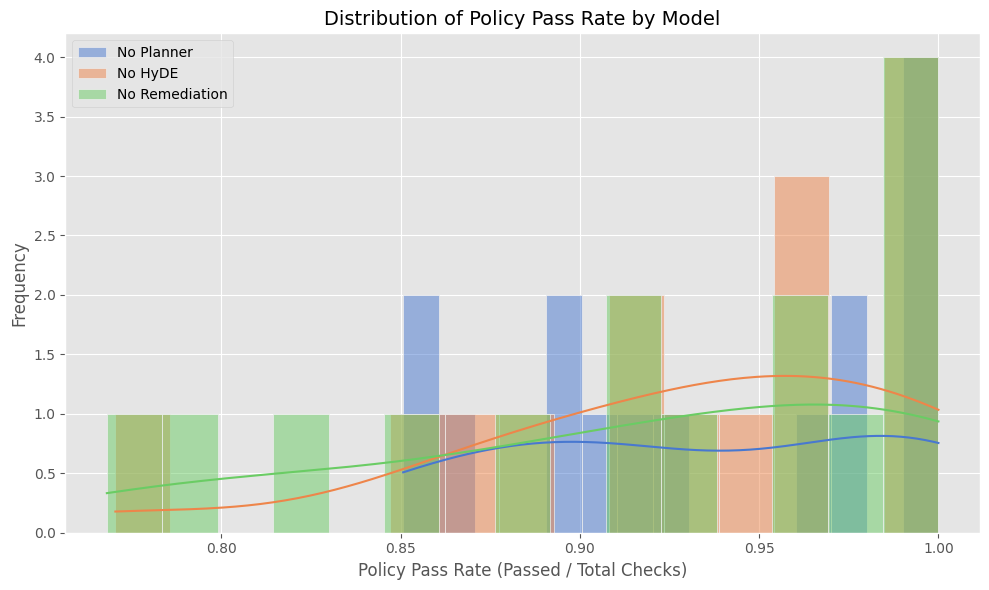

In [16]:
plt.figure(figsize=(10, 6))

for model_name, df in merged_dataframes.items():
    # Drop NaNs just in case some run_ids had no audit results
    valid_rates = df["Policy Pass Rate"].dropna()
    sns.histplot(valid_rates, kde=True, label=model_name, bins=15, alpha=0.5)

plt.title("Distribution of Policy Pass Rate by Model", fontsize=14)
plt.xlabel("Policy Pass Rate (Passed / Total Checks)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

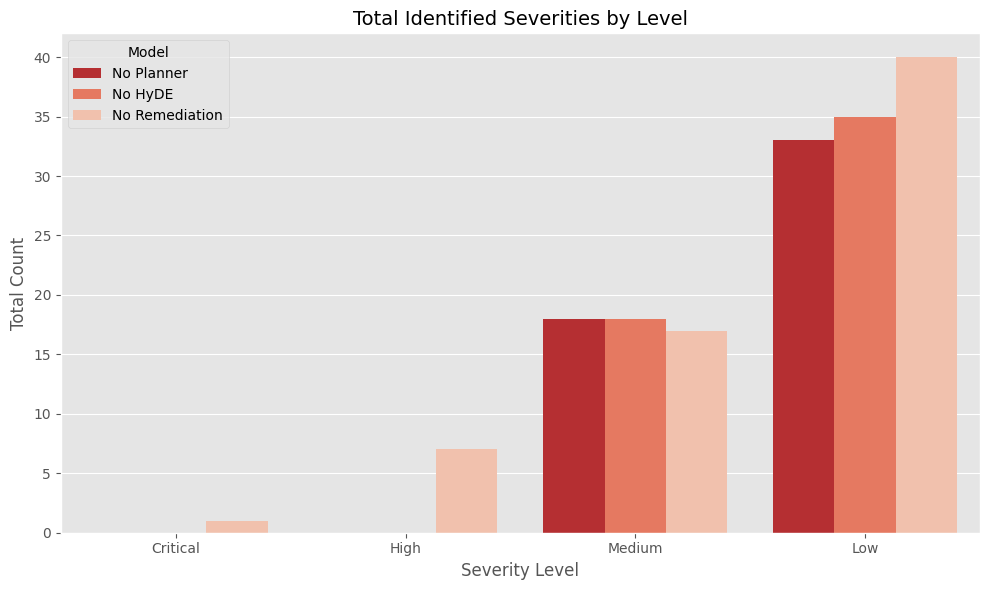

In [17]:
severity_cols = ['severity_critical', 'severity_high', 'severity_medium', 'severity_low']
severity_data = []

# Aggregate severity counts across all models
for model_name, df in merged_dataframes.items():
    for col in severity_cols:
        if col in df.columns:
            total = df[col].sum()
            # Clean up the column name for the plot (e.g., 'severity_critical' -> 'Critical')
            clean_label = col.replace("severity_", "").capitalize()
            severity_data.append({"Model": model_name, "Severity": clean_label, "Count": total})

sev_df = pd.DataFrame(severity_data)

if not sev_df.empty:
    plt.figure(figsize=(10, 6))
    # Using a red color palette to emphasize risk levels
    sns.barplot(data=sev_df, x="Severity", y="Count", hue="Model", palette="Reds_r")
    plt.title("Total Identified Severities by Level", fontsize=14)
    plt.xlabel("Severity Level", fontsize=12)
    plt.ylabel("Total Count", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No severity columns found to plot.")

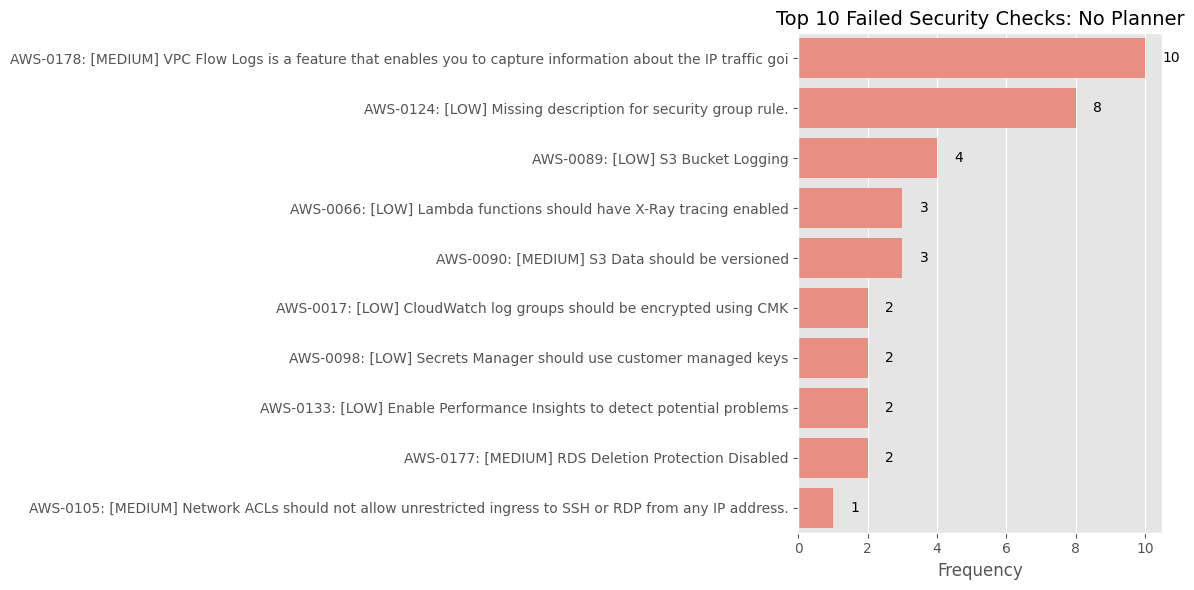

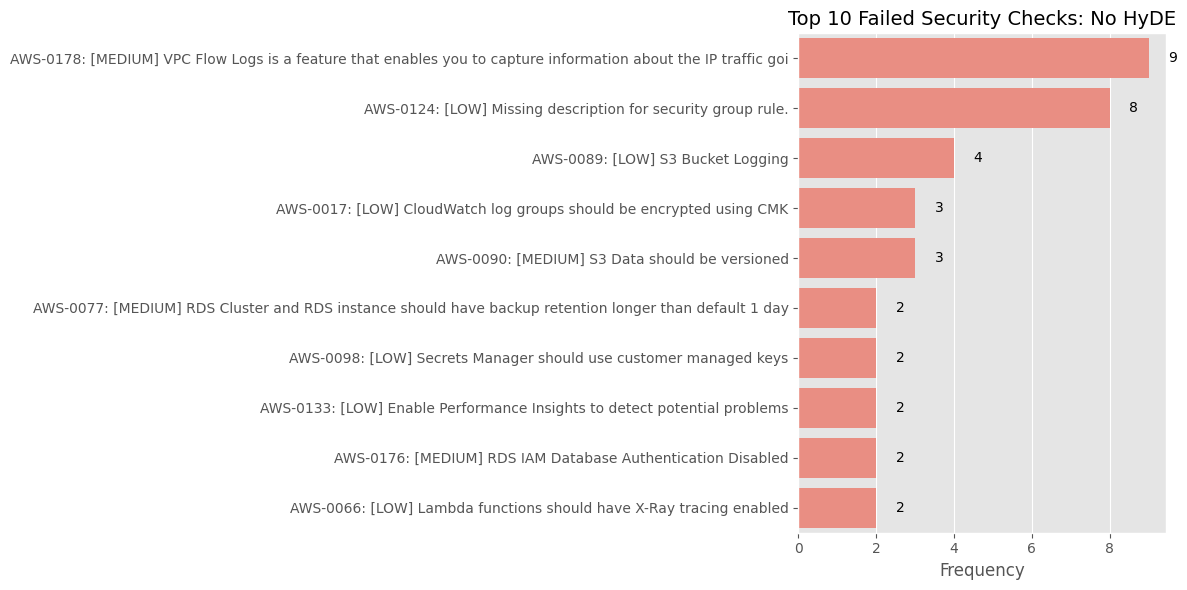

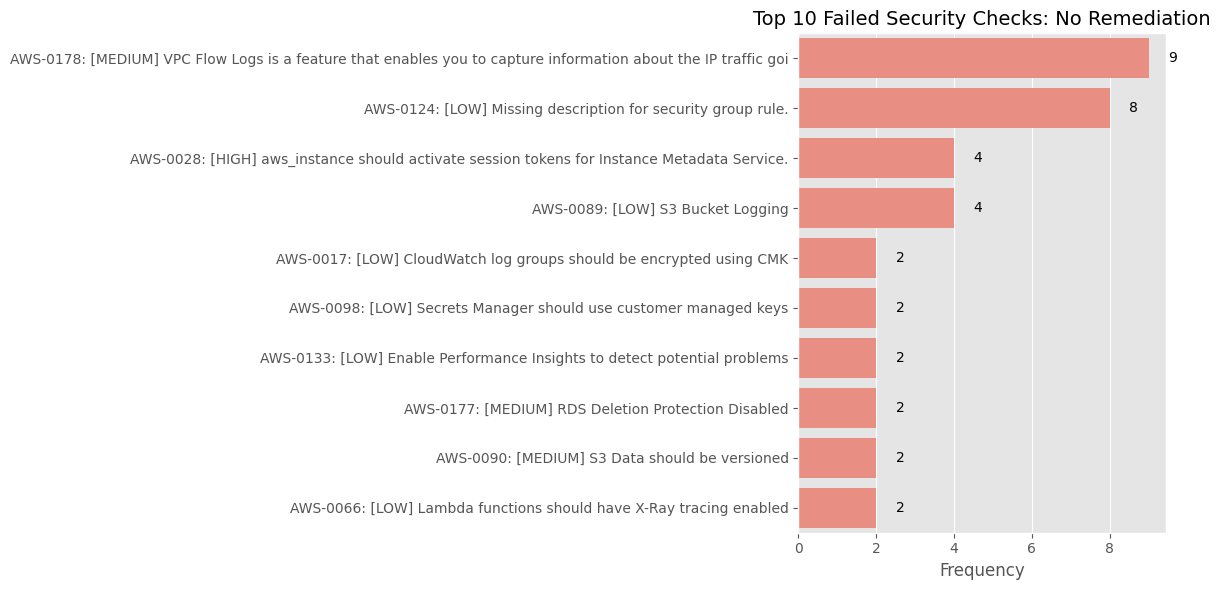

In [18]:
def get_policy_name(check_id):
    """
    Attempts to find the policy name by exact match or regex.
    Returns a combined string of 'ID: Name'.
    """
    # 1. Exact match
    if check_id in policy_mapping:
        return f"{check_id}: {policy_mapping[check_id][:100]}"  # Truncate name for better display
    
    # 2. Regex match to extract 'AWS-XXX' if it exists
    base_match = re.search(r'(AWS-\d+)', check_id)
    if base_match:
        base_id = base_match.group(1)
        if base_id in policy_mapping:
            return f"{check_id}: {policy_mapping[base_id][:100]}"  # Truncate name for better display
            
    # 3. Fallback if no mapping is found
    return check_id

# Generate a plot for each model
for model_name, df in merged_dataframes.items():
    failed_checks = []
    
    if 'failed_check_ids' in df.columns:
        # Extract all check IDs
        for checks in df['failed_check_ids'].dropna():
            # The IDs are separated by semicolons
            for check in str(checks).split(';'):
                check = check.strip()
                if check:
                    failed_checks.append(check)
    
    if failed_checks:
        # Get the top 10 most common failures
        counter = Counter(failed_checks)
        top_10 = counter.most_common(10)
        
        # Map the IDs to their descriptions
        top_10_mapped = [(get_policy_name(cid), count) for cid, count in top_10]
        top_df = pd.DataFrame(top_10_mapped, columns=["Check ID & Description", "Frequency"])
        
        # Plot
        plt.figure(figsize=(12, 6))
        sns.barplot(data=top_df, y="Check ID & Description", x="Frequency", color="salmon")
        plt.title(f"Top 10 Failed Security Checks: {model_name}", fontsize=14)
        plt.xlabel("Frequency", fontsize=12)
        plt.ylabel("")
        
        # Add values on the bars for clarity
        for index, value in enumerate(top_df["Frequency"]):
            plt.text(value + 0.5, index, str(value), va='center')
            
        plt.tight_layout()
        plt.show()
    else:
        print(f"No failed checks found for model: {model_name}")

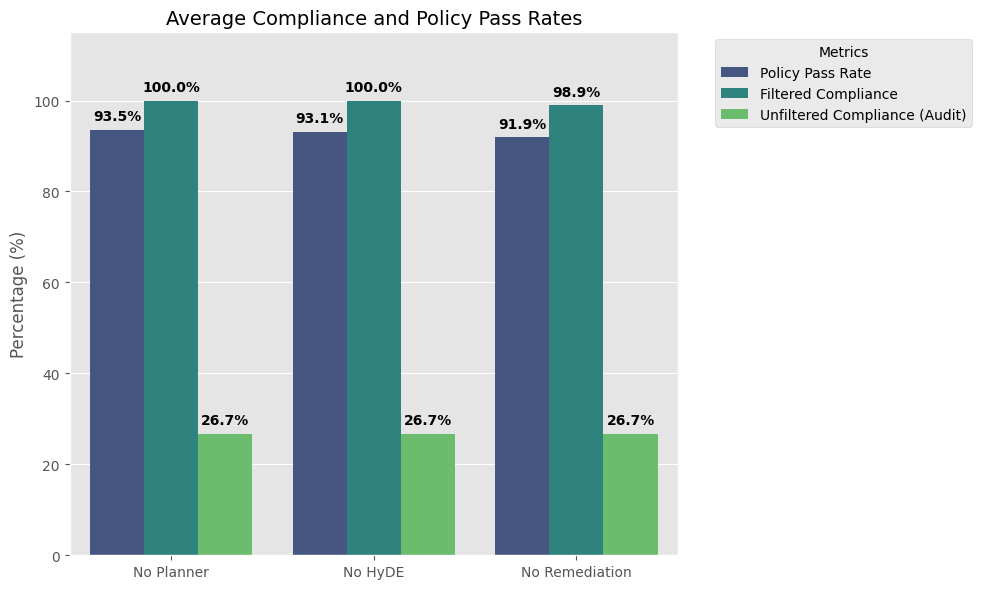

In [19]:
# %%
# Calculate and visualize the requested compliance metrics
compliance_stats = []

for model_name, df in merged_dataframes.items():
    # 1. Average Policy Pass Rate 
    # (Checking for 'scenario_policy_pass_rate' from the result_file. Fallback to calculated Policy Pass Rate)
    if 'scenario_policy_pass_rate' in df.columns:
        avg_policy_pass = df['scenario_policy_pass_rate'].mean() * 100
    else:
        avg_policy_pass = df['Policy Pass Rate'].mean() * 100
        
    # 2. Filtered Compliance Rate (from result_file)
    if 'filtered_compliance_rate' in df.columns:
        avg_filtered_compliance = df['filtered_compliance_rate'].mean() * 100
    else:
        avg_filtered_compliance = 0  # Fallback if column is missing
        
    # 3. Unfiltered Compliance Rate 
    # (Calculated as the percentage of all rows in the audit_file where trivy_passed is True)
    if 'trivy_passed' in df.columns:
        # .mean() on a boolean series calculates the exact ratio of True values
        avg_unfiltered_compliance = (df['trivy_passed'] == True).mean() * 100
    else:
        avg_unfiltered_compliance = 0
    
    # Append to our stats list
    compliance_stats.extend([
        {'Model': model_name, 'Metric': 'Policy Pass Rate', 'Rate (%)': avg_policy_pass},
        {'Model': model_name, 'Metric': 'Filtered Compliance', 'Rate (%)': avg_filtered_compliance},
        {'Model': model_name, 'Metric': 'Unfiltered Compliance (Audit)', 'Rate (%)': avg_unfiltered_compliance}
    ])

# Convert to DataFrame
compliance_df = pd.DataFrame(compliance_stats)

# Plotting the metrics
plt.figure(figsize=(10, 6))
sns.barplot(data=compliance_df, x='Model', y='Rate (%)', hue='Metric', palette='viridis')

plt.title('Average Compliance and Policy Pass Rates', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('')
plt.ylim(0, 115) # Give headroom for labels

# Annotate the bars with the exact percentage
for p in plt.gca().patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        plt.gca().text(
            p.get_x() + p.get_width() / 2., 
            height + 1.5, 
            f'{height:.1f}%', 
            ha='center', 
            va='bottom', 
            fontsize=10,
            fontweight='bold'
        )

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Metrics")
plt.tight_layout()
plt.show()